# ii. Introduction to Python 2
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gem-epidemics/colab/blob/master/iddinf/ii_intro_to_python_2.ipynb)

## LEARNING OUTCOMES
- Use matrix multiplication to vectorise a calculation across multiple
  populations
- Write your own functions, and understand and write simple decorators
- Visualise epidemiological data with `matplotlib`
- Build on and experiment with a simple stochastic epidemic simulation

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Matrix multiplication

Recall from notebook 1 that `np.matmul` multiplies
matrices together, broadcasting over any leading "batch" dimensions and
operating on the trailing two axes.

Let's try using `np.matmul` in a force of infection calculation.

We have 3 populations, each with a current proportion of infected
individuals, and a **contact matrix** describing how strongly each pair of
populations is linked (population $i$'s row tells us how much weight to
give population $j$'s infections, via `contact_mat[i, j]`).

In [40]:
contact_mat = np.array([
    [0.0, 0.6, 0.5],
    [0.5, 0.0, 0.3],
    [0.4, 0.3, 0.0],
])

prop_inf = np.array([0.10, 0.05, 0.20])  # proportion infected in each population

Here's one way to compute the between-population contribution to each
population's force of infection: for each population `i`, take the dot
product of its row of `contact_mat` with `prop_inf`.

In [41]:
between_loop = np.zeros(3)

for i in range(3):
    between_loop[i] = np.sum(contact_mat[i, :] * prop_inf)

print(between_loop)

[0.13  0.11  0.055]


````{exercise-start}
:label: exii.1
````

1. Replace the loop with a matrix multiplication.
2. Check your matmul result matches `between_loop` using `np.allclose`.
3. A population's force of infection combines this between-population
   term with a **within-population** term (`beta_within * prop_inf`). Using
   `beta_within = 0.5` and `beta_between = 0.1`, compute the force of
   infection for each population as
   `beta_within * prop_inf + beta_between * (contact_mat @ prop_inf)`.
4. Which population has the highest force of infection? Does that
   match what you'd expect, given `prop_inf` and `contact_mat`?


````{exercise-end}
````

````{solution-start} exii.1
:class: dropdown
````

In [42]:
# Solution 1.1
between_matmul = np.matmul(contact_mat, prop_inf)
print(between_matmul)

[0.13  0.11  0.055]


In [43]:
# Solution 1.2
print(np.allclose(between_matmul, between_loop))

True


In [44]:
# Solution 1.3
beta_within = 0.5
beta_between = 0.1

foi = beta_within * prop_inf + beta_between * between_matmul
print(foi)

[0.063  0.036  0.1055]


In [45]:
# Solution 1.4
print(f"Population {np.argmax(foi)} has the highest force of infection")

Population 2 has the highest force of infection


````{solution-end}
````

Beyond being shorter to write, the matmul version is also much faster once
you have many populations or many time steps as `numpy` runs the
multiply-and-sum in optimised, compiled code rather than a Python `for`
loop. We'll use exactly this trick later today to extend our epidemic
simulation to more than one population.

Note, we can also use the `@` operator for matrix multiplication in Python. This does exactly the same row-by-row dot product, for all rows at once.

In [46]:
between_matmul = contact_mat @ prop_inf
print(between_matmul)

[0.13  0.11  0.055]


## Functions

### Writing your own functions
A function is a reusable block of code which only runs when you call it. It helps reduce code repetition, you can reuse the same code with different inputs.

The basic syntax is:

```python
def function_name(arg1, arg2, keyword_arg=default_value):
    # one-line description of what the function does
    
    # function body
    result = arg1 * arg2 * keyword_arg

    return result
```

- `arg1`, `arg2` are **positional arguments**, you must supply them.
- `keyword_arg=default_value` gives an argument a **default value**, so it's
  optional when calling the function.
- `return` sends a value back to the caller. All functions have a return value, either implicit or explicit. If you omit a
  `return` statement, a function implicitly returns `None`.

When we call a function, we can pass its arguments in two different ways. Take a function that computes the exponential growth rate from its transmission rate `beta` and recovery rate `gamma`.

In [47]:
def exp_growth_rate(beta, gamma):
    return beta - gamma

We can pass arguments **positionally**, in the order the function expects them:

In [48]:
exp_growth_rate(0.5, 0.2)

0.3

The order matters when arguments are passed positionally, if we were to swap them you'd get a completely different answer.

In [49]:
print(exp_growth_rate(0.3, 0.1))  # beta=0.3, gamma=0.1 -> growing outbreak
print(exp_growth_rate(0.1, 0.3))  # beta=0.1, gamma=0.3 -> declining outbreak

0.19999999999999998
-0.19999999999999998


However, position doesn't matter when arguments are passed by name:

In [50]:
print(exp_growth_rate(beta=0.3, gamma=0.1))
print(exp_growth_rate(gamma=0.1, beta=0.3))

0.19999999999999998
0.19999999999999998


If you run `help` on a function, Python will tell you its argument names:

In [51]:
help(exp_growth_rate)

Help on function exp_growth_rate in module __main__:

exp_growth_rate(beta, gamma)



A function can also return **more than one value** at once, separated by commas. Python packs them into a tuple, which you can unpack directly when calling the function:

```python
def sir_counts(state):
    susceptible, infected, removed = state
    return susceptible, infected, removed

s, i, r = sir_counts([90, 5, 5])
print(s, i, r)
```

We'll use exactly this pattern later today, when our simulation functions return the susceptible/infected/removed counts at every time step.

Now, let's define a very simple function which checks how many people are below and above a certain age threshold.

In [52]:
def summarise_ages(ages, age_threshold=18):
    ages = np.asarray(ages)
    n_below = int(np.sum(ages < age_threshold))
    n_at_or_above = int(np.sum(ages >= age_threshold))
    return {"below": n_below, "at_or_above": n_at_or_above}


print(summarise_ages([5, 12, 20, 45, 70]))
print(summarise_ages([5, 12, 20, 45, 70], age_threshold=30))
print(summarise_ages(24))

{'below': 2, 'at_or_above': 3}
{'below': 3, 'at_or_above': 2}
{'below': 0, 'at_or_above': 1}


````{exercise-start}
:label: exii.2
````

Now it's your turn. Write a new function `infectious_period` that takes a recovery rate
`gamma` and returns the average infectious period: `1 / gamma`.

Compute the infectious period when `gamma=0.1` and `gamma=0.2`.

````{exercise-end}
````

````{solution-start} exii.2
:class: dropdown
````

In [53]:
# Solution
def infectious_period(gamma):
    return 1 / gamma

In [54]:
print(infectious_period(0.1))
print(infectious_period(0.2))

10.0
5.0


````{solution-end}
````

### Inner Functions

We can also define functions inside another function, these are called inner functions (also known as nested functions).

They are often used to:

*   provide encapsulation, so that the inner function is hidden from global scope
*   act as help functions used only within the enclosing function
* build closures and decorators (we'll come back to this).


As an example let's create a function which checks whether a set of initial conditions are valid for an epidemic model. We'll check that the compartment counts add up to the total population size, and that none of them are negative.

In [55]:
def make_initial_condition_checker(population):
    def check_initial_conditions(state):
        if sum(state) != population:
            raise ValueError("compartment counts must add up to the population size")
        if any(count < 0 for count in state):
            raise ValueError("all compartment counts must be non-negative")
        return True
    return check_initial_conditions

In [56]:
check_initial_conditions = make_initial_condition_checker(population=100)
check_initial_conditions([99, 1, 0])  # True

True

In [57]:
# we can change the number of states (SIR model to an SEIR model)
check_initial_conditions([95, 4, 1, 0])

True

In [58]:
try:
    check_initial_conditions([95, 6, -1])
except ValueError as e:
    print(f"ValueError: {e}")

ValueError: all compartment counts must be non-negative


`check_initial_conditions` is defined *inside* `make_initial_condition_checker`:
it needs access to `population`, and it's returned so you get a ready-to-use checker for *this* population size. Enabling you to call `check_initial_conditions(...)` on different starting states without passing `population`in each time.

## Decorators

Decorators enable you to modify or extend the behaviour of a function without changing the function's code. In this course you won't need to write your own decorators from scratch, but it's useful to be able to recognise one and know how to apply it.

Here we define a new decorator called `timeit_dec`




In [59]:
import time


def timeit_dec(func):
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        elapsed = time.perf_counter() - start
        print(f"{func.__name__} took {elapsed:.4f}s")
        return result
    return wrapper


`wrapper` records the time just before and just after calling the original function, prints how long it took, and returns whatever the original function returned.

To apply a decorator to a function, write `@decorator_name` on the line just above the function definition:

That's all it takes to use a decorator: `@timeit_dec` here means every
call to `slower_square` is automatically timed, without changing anything
inside `slower_square` itself.

In [60]:
@timeit_dec
def slower_square(n):
    return [i ** 2 for i in range(n)]


_ = slower_square(1_000_000)

slower_square took 0.0219s


````{exercise-start}
:label: exii.3
````

1. Apply `@timeit_dec` to the `infectious_period` function you defined above.

2. Run your decorated `infectious_period` twice in a row. Are the two printed times identical? What does that tell you about timing a function this way?

````{exercise-end}
````

````{solution-start} exii.3
:class: dropdown
````

In [61]:
# Solution
@timeit_dec
def infectious_period(gamma):
    return 1 / gamma


print(infectious_period(0.1))

infectious_period took 0.0000s
10.0


````{solution-end}
````

## Plotting

`matplotlib` is  one of the main plotting library in Python. `pandas` DataFrames have a convenient `.plot()` method built on top of it. You'll likely also come across seaborn (built on matplotlib, with nicer default styling and some convenient statistical plot types) and interactive libraries such as plotly.

For this sections, we'll reuse the Hagelloch measles dataset from earlier to plot some epidemic trajectories.

In [62]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    HAGELLOCH_DATA = (
        "https://drive.google.com/uc?export=download&id=1T-O_51EsNy2FmqnHkR_7pHZnDGC28IeC"
    )
else:
    HAGELLOCH_DATA = "data/hagelloch.csv"  
data = pd.read_csv(HAGELLOCH_DATA)

In [63]:
# PRO = date of prodrome (early symptoms), ERU = date of rash eruption
data["PRO"] = pd.to_datetime(data["PRO"])
data["ERU"] = pd.to_datetime(data["ERU"])

data[["PN", "AGE", "SEX", "PRO", "ERU", "CL"]].head()

,PN,AGE,SEX,PRO,ERU,CL
0,1,7.0,female,1861-11-21,1861-11-25,1st class
1,2,6.0,female,1861-11-23,1861-11-27,1st class
2,3,4.0,female,1861-11-28,1861-12-02,preschool
3,4,13.0,male,1861-11-27,1861-11-28,2nd class
4,5,8.0,female,1861-11-22,1861-11-27,1st class


Let's first count how many cases had their rash appear on each date, then accumulate that over time.

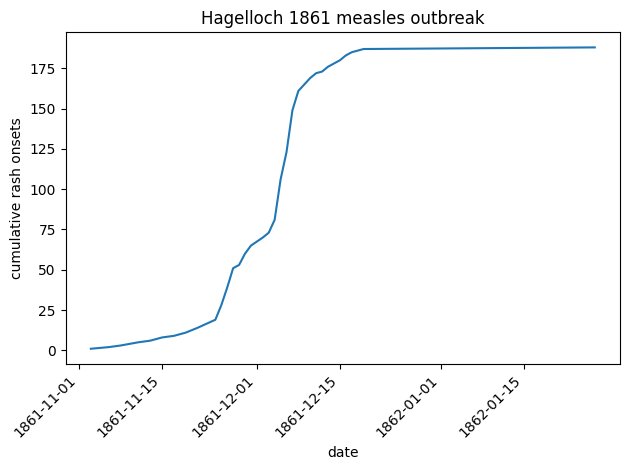

In [64]:
daily_new = data.groupby("ERU").size()
cumulative = daily_new.cumsum()

fig, ax = plt.subplots()
cumulative.plot(ax=ax, kind="line")
ax.set_xlabel("date")
ax.set_ylabel("cumulative rash onsets")
ax.set_title("Hagelloch 1861 measles outbreak")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

````{exercise-start}
:label: exii.4
````

1. `tI`, `tPRO` and `tERU` record the same three events as `PRO`/`ERU` (becoming infectious, prodrome onset, rash onset) but as a day count since the epidemic began, rather than calendar dates. Build a cumulative curve for each of `tI`, `tPRO` and `tERU`, and plot all three on the same axes. Which rises first, is it the one you expected?

2. `data["CL"]` records each case's school class (`preschool`, `1st class`, `2nd class`). Using `.groupby("CL")`, plot a *separate* cumulative `ERU` curve for each class on one set of axes, with a legend.

3. Each case has a patient number `PN`, and `IFTO` records the `PN` of
   that case's putative infector (`0` if unknown, e.g. for an index
   case). `x.loc` and `y.loc` give the case's house location, in metres.

   The straight-line (Euclidean) distance between two points $(x_1, y_1)$
   and $(x_2, y_2)$ is:

   $$
   d = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}
   $$

   Write a function `euclidean_distance(x1, y1, x2, y2)` that computes
   the euclidean distance between two points. Then, for cases with a
   known infector, look up their infector's house coordinates and use
   your function to compute the distance between each case's house and
   their infector's house.

   Add this as a new column, and plot a histogram of these transmission
   distances.

````{exercise-end}
````

````{solution-start} exii.4
:class: dropdown
````

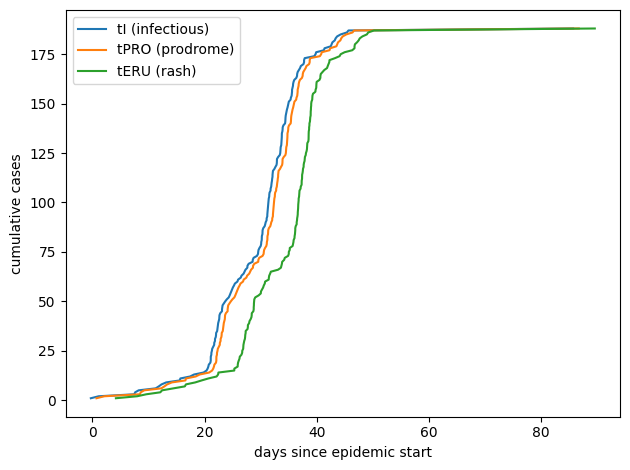

In [65]:
# Solution 1
tI_cumulative = data.groupby("tI").size().cumsum()
tpro_cumulative = data.groupby("tPRO").size().cumsum()
teru_cumulative = data.groupby("tERU").size().cumsum()

fig, ax = plt.subplots()
tI_cumulative.plot(ax=ax, label="tI (infectious)")
tpro_cumulative.plot(ax=ax, label="tPRO (prodrome)")
teru_cumulative.plot(ax=ax, label="tERU (rash)")
ax.set_xlabel("days since epidemic start")
ax.set_ylabel("cumulative cases")
ax.legend()
plt.tight_layout()
plt.show()

Reindex each class's series onto the *full* range of dates in the dataset, carrying the last known cumulative total forward until the next case.

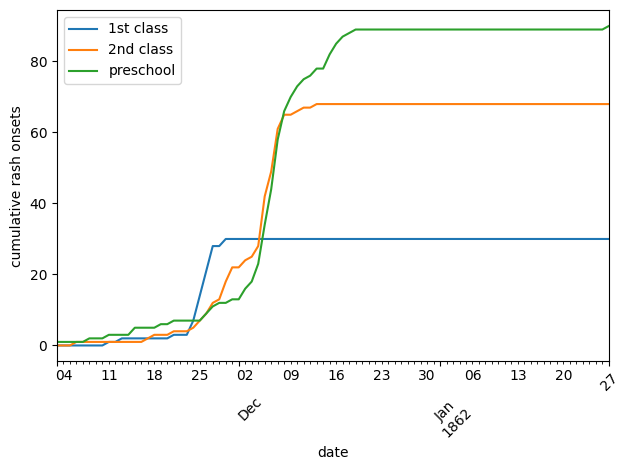

In [66]:
# Solution 2
full_range = pd.date_range(data["ERU"].min(), data["ERU"].max(), freq="D")

fig, ax = plt.subplots()
for cl, group in data.groupby("CL"):
    counts = group.groupby("ERU").size().cumsum()
    counts = counts.reindex(full_range).ffill().fillna(0)
    counts.plot(ax=ax, label=cl)

ax.set_xlabel("date")
ax.set_ylabel("cumulative rash onsets")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

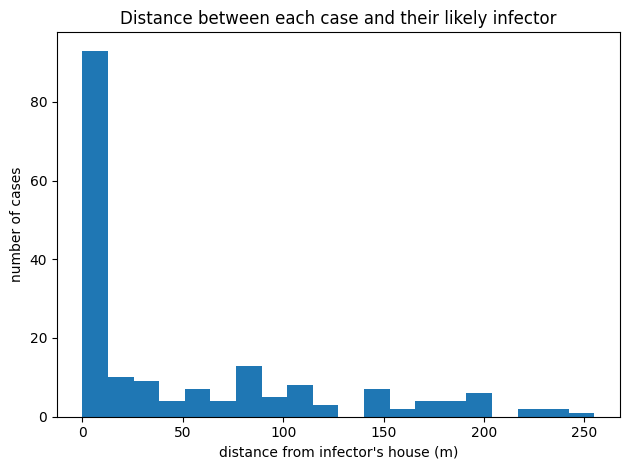

In [67]:
# Solution 3

def euclidean_distance(x1, y1, x2, y2):
    return ((x1 - x2) ** 2 + (y1 - y2) ** 2) ** 0.5


# table of household coordinates for each patient number
coords = data.set_index("PN")[["x.loc", "y.loc"]]

# only cases with a known infector (IFTO recorded and not 0/na)
infected = data[data["IFTO"].notna() & (data["IFTO"] != 0)].copy()
infected["IFTO"] = infected["IFTO"].astype(int)
infector_coords = coords.loc[infected["IFTO"].values]

infected["transmission_distance"] = euclidean_distance(
    infected["x.loc"].values,
    infected["y.loc"].values,
    infector_coords["x.loc"].values,
    infector_coords["y.loc"].values,
)

# plot a histogram showing the distance between the home location of each case
# and their likely infector
fig, ax = plt.subplots()
infected["transmission_distance"].plot(ax=ax, kind="hist", bins=20)
ax.set_xlabel("distance from infector's house (m)")
ax.set_ylabel("number of cases")
ax.set_title("Distance between each case and their likely infector")
plt.tight_layout()
plt.show()

````{solution-end}
````

## Simulating an epidemic

We'll now build a simple stochastic SIR simulation, similar to the models used throughout this course, but written in plain `numpy` so we can focus on the Python rather than any modelling framework.

Below is some example code of how you could code up a stochastic discrete time SIR model.

In [68]:
def sir_propagate(state, time_delta, beta, gamma):
    """Advance an SIR state forward by one time step."""
    num_susceptible, num_infected, num_removed = state

    # rates -> per-step probabilities
    i_prob = 1 - np.exp(-beta * num_infected * time_delta)
    r_prob = 1 - np.exp(-gamma * time_delta)

    num_new_infections = np.random.binomial(num_susceptible, i_prob)
    num_new_removals = np.random.binomial(num_infected, r_prob)

    return [
        num_susceptible - num_new_infections,
        num_infected + num_new_infections - num_new_removals,
        num_removed + num_new_removals,
    ]

In [69]:
def simulate(initial_state, num_steps, beta, gamma, time_delta=1):
    """Run an SIR simulation for `num_steps` steps and return the trajectory."""
    S = np.zeros(num_steps)
    I = np.zeros(num_steps)
    R = np.zeros(num_steps)

    state = list(initial_state)
    for ii in range(num_steps):
        state = sir_propagate(state, time_delta, beta, gamma)
        S[ii], I[ii], R[ii] = state

    return {
        "Time": np.arange(num_steps) * time_delta,
        "Susceptible": S,
        "Infected": I,
        "Removed": R,
    }

For a *stochastic* simulation we need some element of randomness. Here,  `np.random.binomial` will  give a different result every time you run it.  To make results reproducible, where we get the same "random" numbers each time the code is run, we can fix the random seed with `np.random.seed(some_number)` right before generating any random numbers.

You'll see two different uses of this below: setting the **same** seed before runs with different parameters, so any difference you see is really down to the parameter change and not just random noise; and setting a **different** seed for each of several runs, to deliberately generate several distinct stochastic realisations of the same model.

````{exercise-start}
:label: exii.5
````

1. Take some time comparing this Python code with your own simulation code in R (or another language), what's similar, and what's different?.
2. Write your own code to plot the epidemic curve, showing the number of people in each of the `S`, `I` and `R` compartments over time.
3. Run the simulation again with a *smaller* `beta` (try `0.0015`) and a *larger* `beta` (try `0.005`), keeping everything else the same. For each, print the peak number infected and the final number removed.

````{exercise-end}
````

````{solution-start} exii.5
:class: dropdown
````

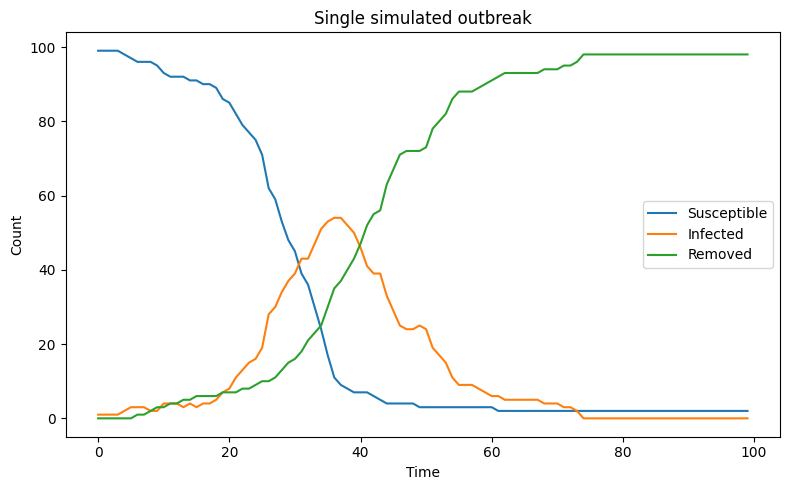

In [70]:
# Solution 2
np.random.seed(0)
baseline = simulate([99, 1, 0], num_steps=100, beta=0.003, gamma=0.1)

plt.figure(figsize=(8, 5))
plt.plot(baseline["Time"], baseline["Susceptible"], label="Susceptible")
plt.plot(baseline["Time"], baseline["Infected"], label="Infected")
plt.plot(baseline["Time"], baseline["Removed"], label="Removed")
plt.xlabel("Time")
plt.ylabel("Count")
plt.title("Single simulated outbreak")
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
# Solution
for beta in [0.0015, 0.003, 0.005]:
    np.random.seed(0)
    result = simulate([99, 1, 0], num_steps=100, beta=beta, gamma=0.1)
    print(
        f"beta={beta}: peak infected={result['Infected'].max():.0f}, "
        f"final removed={result['Removed'][-1]:.0f}"
    )

# Larger beta gives a bigger, faster, more certain outbreak; smaller beta
# gives a smaller, slower outbreak that is more likely to fade out by
# chance before it takes off.

beta=0.0015: peak infected=23, final removed=74
beta=0.003: peak infected=54, final removed=98
beta=0.005: peak infected=48, final removed=100


````{solution-end}
````

````{exercise-start}
:label: exii.6
````

Run the baseline simulation (`beta=0.003, gamma=0.1`) **10 times**, using a
different random seed each time, and overlay all 10 `Infected` trajectories
on one plot. What do you notice about how similar (or different) the runs
are?

In [72]:
# run 10 realisations and overlay their Infected trajectories

````{exercise-end}
````

````{solution-start} exii.6
:class: dropdown
````

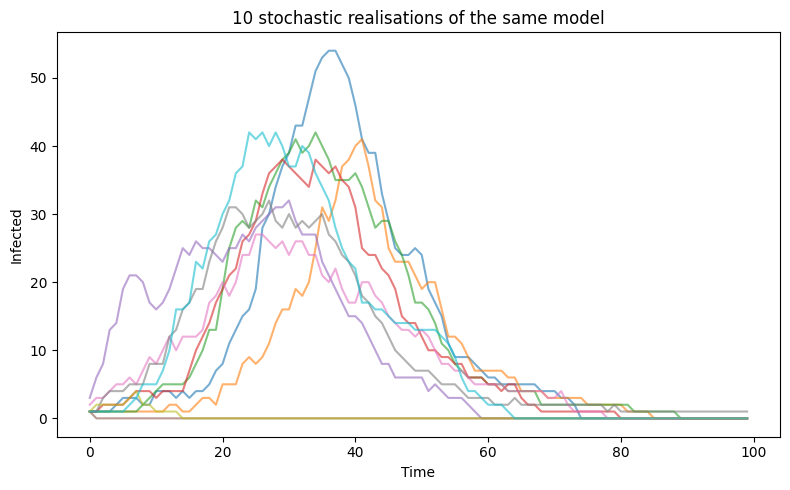

In [73]:
# Solution
plt.figure(figsize=(8, 5))
for seed in range(10):
    np.random.seed(seed)
    result = simulate([99, 1, 0], num_steps=100, beta=0.003, gamma=0.1)
    plt.plot(result["Time"], result["Infected"], alpha=0.6)

plt.xlabel("Time")
plt.ylabel("Infected")
plt.title("10 stochastic realisations of the same model")
plt.tight_layout()
plt.show()

````{solution-end}
````

### Further exercises

````{exercise-start}
:label: exii.7
````

1. Apply your `@timeit_dec` decorator to the `simulate` function, and time it
for `num_steps` of `50`, `200`, and `1000` (keep `beta`/`gamma` fixed). Does
the runtime scale roughly linearly with `num_steps`?

2. Extend the simulation to a metapopulation with two
populations using a contact matrix and matrix multiplication to compute `i_prob`.

*If you get stuck with this, have a look at the solution, and try to extend the model to a third population instead*

In [74]:
# apply @timeit_dec to simulate and compare runtimes for different num_steps

````{exercise-end}
````

````{solution-start} exii.7
:class: dropdown
````

In [75]:
# Solution 1
@timeit_dec
def timed_simulate(initial_state, num_steps, beta, gamma, time_delta=1):
    return simulate(initial_state, num_steps, beta, gamma, time_delta)


for num_steps in [50, 200, 1000]:
    _ = timed_simulate([99, 1, 0], num_steps, beta=0.003, gamma=0.1)

timed_simulate took 0.0001s
timed_simulate took 0.0003s
timed_simulate took 0.0013s


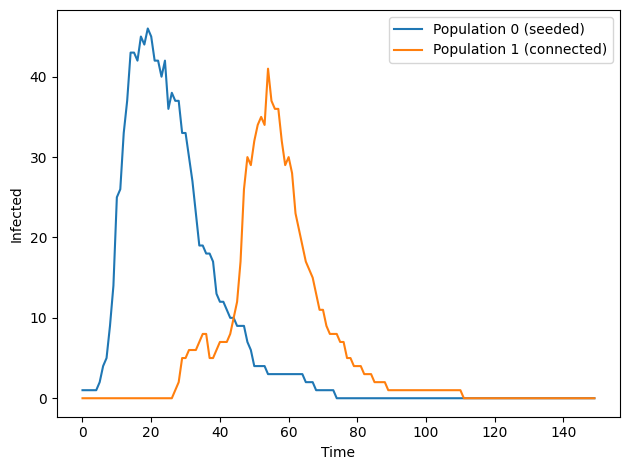

In [76]:
# Solution 2

def two_pop_propagate(states, time_delta, beta_within, beta_between, gamma, contact_mat):
    states = np.array(states, dtype=float)
    I = states[:, 1]

    within = beta_within * I
    between = beta_between * (contact_mat @ I)
    foi = within + between

    i_prob = 1 - np.exp(-foi * time_delta)
    r_prob = 1 - np.exp(-gamma * time_delta)

    new_inf = np.random.binomial(states[:, 0].astype(int), i_prob)
    new_rem = np.random.binomial(states[:, 1].astype(int), r_prob)

    return np.stack([
        states[:, 0] - new_inf,
        states[:, 1] + new_inf - new_rem,
        states[:, 2] + new_rem,
    ], axis=1)


def simulate_two_pop(initial_states, num_steps, beta_within, beta_between, gamma, contact_mat, time_delta=1):
    state = np.array(initial_states, dtype=float)
    out = np.zeros((num_steps, 2, 3))
    for t in range(num_steps):
        state = two_pop_propagate(state, time_delta, beta_within, beta_between, gamma, contact_mat)
        out[t] = state
    return out


contact_mat = np.array([[0.0, 1.0], [1.0, 0.0]])
np.random.seed(1)
res = simulate_two_pop(
    [[99, 1, 0], [100, 0, 0]], num_steps=150,
    beta_within=0.005, beta_between=0.00001, gamma=0.1, contact_mat=contact_mat,
)

plt.plot(res[:, 0, 1], label="Population 0 (seeded)")
plt.plot(res[:, 1, 1], label="Population 1 (connected)")
plt.xlabel("Time")
plt.ylabel("Infected")
plt.legend()
plt.tight_layout()
plt.show()

````{solution-end}
````